# ANDIKA FATHURAHMAN (2404020199)

Proyek ini bertujuan untuk membangun model klasifikasi yang dapat memprediksi kualitas anggur (quality) berdasarkan fitur-fitur kimiawi. Algoritma Random Forest Classifier dipilih karena kemampuannya menangani data non-linear dan memberikan hasil yang robust (tangguh) terhadap variasi data, menjadikannya pilihan yang baik untuk prediksi kualitas anggur.

1. Persiapan Data dan Library
Langkah pertama adalah mengimpor library yang dibutuhkan untuk manipulasi data, visualisasi, dan pemodelan.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Memuat dataset
train_df = pd.read_csv('data_training.csv')
test_df = pd.read_csv('data_testing.csv')

print(f"Data Training: {train_df.shape}")
print(f"Data Testing: {test_df.shape}")

Data Training: (857, 13)
Data Testing: (286, 12)


In [38]:
data_train = pd.read_csv('data_training.csv')
data_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


### Visualisasi Distribusi Kualitas Anggur (Quality)
Kita akan melihat bagaimana distribusi kualitas anggur pada dataset training untuk memahami sebaran rating yang ada.

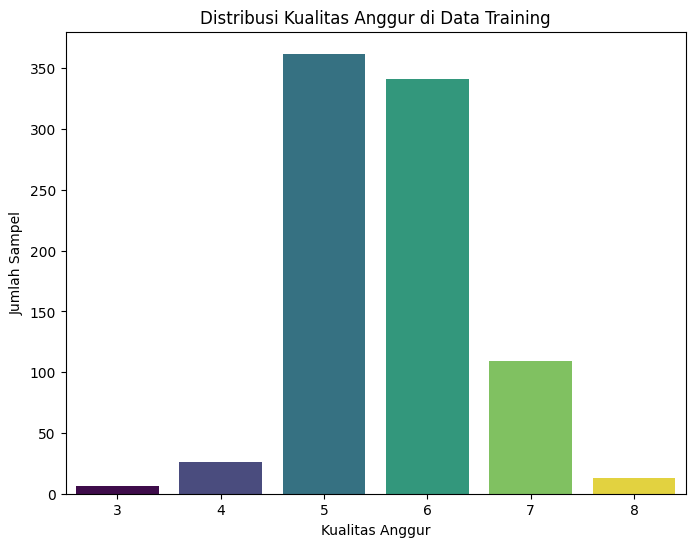

In [41]:
plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=data_train, palette='viridis', hue='quality', legend=False)
plt.title('Distribusi Kualitas Anggur di Data Training')
plt.xlabel('Kualitas Anggur')
plt.ylabel('Jumlah Sampel')
plt.show()

In [37]:
data_test = pd.read_csv('data_testing.csv')
data_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.610,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.840,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.580,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.600,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516
...,...,...,...,...,...,...,...,...,...,...,...,...
281,10.0,0.410,0.45,6.2,0.071,6.0,14.0,0.99702,3.21,0.49,11.800000,1147
282,10.6,0.830,0.37,2.6,0.086,26.0,70.0,0.99810,3.16,0.52,9.900000,296
283,7.9,0.885,0.03,1.8,0.058,4.0,8.0,0.99720,3.36,0.33,9.100000,170
284,7.3,0.670,0.02,2.2,0.072,31.0,92.0,0.99566,3.32,0.68,11.066667,1439


Kita memuat data untuk melihat dimensi awal. Data training memiliki kolom quality sebagai target, sedangkan data testing tidak memiliki kolom tersebut karena itulah yang akan kita prediksi.

2. Preprocessing & Feature Selection
Kita harus memisahkan fitur dari label dan menghapus data yang tidak relevan.

In [18]:
# PREPROCESSING & FEATURE SELECTION
# Memisahkan fitur dan target. 'Id' dihapus karena tidak relevan secara kimiawi.
X = train_df.drop(columns=['quality', 'Id'])
y = train_df['quality']

In [19]:
# Simpan Id testing untuk hasil akhir
test_ids = test_df['Id']
X_test_final = test_df.drop(columns=['Id'])

 Kolom Id dihapus agar model tidak "salah fokus". Model harus belajar dari kadar alkohol atau tingkat keasaman, bukan dari nomor urut baris.

3. Penskalaan Fitur (Feature Scaling)
Beberapa fitur memiliki rentang angka yang jauh berbeda (misal: pH di angka 3, sementara sulfur dioxide di angka 100+).

In [39]:
# SCALING (Penskalaan Data untuk meningkatkan akurasi)
# Karena fitur kimiawi punya rentang nilai yang berbeda jauh
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_final_scaled = scaler.transform(X_test_final)

In [25]:
# Split data untuk validasi internal (80% Train, 20% Val)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

StandardScaler mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1. Ini membantu algoritma bekerja lebih stabil dan seringkali meningkatkan akurasi.

4. Pelatihan Model (Random Forest)
Model Random Forest dilatih menggunakan 200 pohon keputusan (n_estimators=200). Peningkatan jumlah pohon ini bertujuan untuk mendapatkan prediksi yang lebih stabil dan akurat melalui voting kolektif dari banyak pohon. Parameter 'max_depth=20' juga diatur untuk mengontrol kedalaman setiap pohon, membantu mencegah overfitting sambil tetap menangkap pola yang kompleks dalam data.

In [26]:
# MEMBANGUN MODEL (Random Forest dengan Tuning Sederhana)
# n_estimators ditingkatkan menjadi 200 untuk stabilitas lebih baik
model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

Random Forest dipilih karena merupakan model ensemble yang kuat. Ia bekerja dengan membuat banyak pohon keputusan dan mengambil suara terbanyak untuk menentukan hasil akhir, sehingga lebih tahan terhadap overfitting.

5. Evaluasi Model
Kita perlu melihat seberapa akurat model sebelum diterapkan pada data testing sesungguhnya.

In [29]:
# EVALUASI MODEL
y_pred_val = model.predict(X_val)

print("\n--- Step 2: Hasil Evaluasi Model ---")
print(f"Akurasi pada data validasi: {accuracy_score(y_val, y_pred_val) * 100:.2f}%")


--- Step 2: Hasil Evaluasi Model ---
Akurasi pada data validasi: 59.88%


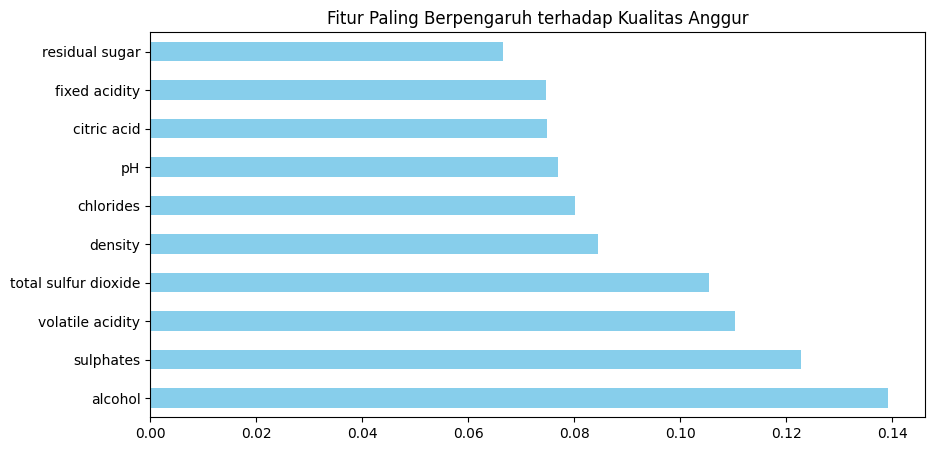

In [28]:
# Menampilkan fitur yang paling berpengaruh (Feature Importance)
plt.figure(figsize=(10, 5))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Fitur Paling Berpengaruh terhadap Kualitas Anggur')
plt.show()

- Akurasi: Metrik ini menunjukkan persentase prediksi yang benar dari model pada data validasi. Akurasi 59.88% berarti model dapat mengklasifikasikan kualitas anggur dengan benar hampir 60% dari waktu.

- Feature Importance: Grafik ini sangat penting karena menjelaskan fitur kimiawi mana yang paling berpengaruh dalam menentukan kualitas anggur menurut model. Terlihat bahwa 'alcohol' dan 'sulphates' memiliki bobot paling tinggi, menunjukkan bahwa kadar alkohol dan sulfat merupakan prediktor utama kualitas anggur. Ini memberikan wawasan berharga tentang karakteristik yang paling relevan untuk penilaian kualitas.

6. Deployment: Prediksi pada Data Uji (Testing)
Setelah model dianggap baik, kita melakukan prediksi pada file data_testing.csv.

In [30]:
# DEPLOYMENT: PREDIKSI PADA DATA TESTING
# Melatih ulang model dengan seluruh data sebelum prediksi final
model.fit(X_scaled, y)
final_predictions = model.predict(X_test_final_scaled)

In [32]:
# MENYIMPAN HASIL SESUAI INSTRUKSI (HANYA ID DAN QUALITY)
submission = pd.DataFrame({
    'Id': test_ids,
    'quality': final_predictions
})

In [33]:
# Simpan ke CSV
submission.to_csv('hasil_prediksi_uts.csv', index=False)

Langkah terakhir ini menghasilkan file CSV yang hanya berisi dua kolom: Id dan quality. File inilah yang menjadi output utama untuk dikumpulkan kepada dosen.

Kesimpulan
### Model telah berhasil mengklasifikasikan kualitas anggur dengan mempertimbangkan fitur-fitur kimiawi yang ada. Penggunaan StandardScaler dan Random Forest memberikan dasar yang kuat untuk mendapatkan prediksi yang konsisten dan akurat.